In [ ]:
from google.colab import files
files.upload()

Saving archive.zip to archive (1).zip
Buffered data was truncated after reaching the output size limit.

In [3]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_path = "/content/garbage_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os
os.listdir("garbage_dataset")

['garbage classification',
 'one-indexed-files-notrash_train.txt',
 'one-indexed-files.txt',
 'one-indexed-files-notrash_test.txt',
 'Garbage classification',
 'one-indexed-files-notrash_val.txt',
 'zero-indexed-files.txt']

In [5]:
import os
import shutil
import random

source_dir = "/content/garbage_dataset/Garbage classification/Garbage classification"
target_dir = "/content/dataset"

mapping = {
    "cardboard": "recyclable",
    "paper": "recyclable",
    "plastic": "recyclable",
    "glass": "recyclable",
    "metal": "recyclable",
    "trash": "non_recyclable"
}

for folder in ["recyclable","organic","non_recyclable"]:
    os.makedirs(f"{target_dir}/train/{folder}", exist_ok=True)
    os.makedirs(f"{target_dir}/validation/{folder}", exist_ok=True)

for src_class, target_class in mapping.items():

    src_path = os.path.join(source_dir, src_class)

    if not os.path.exists(src_path):
        print(f"Skipping {src_class}, folder not found")
        continue

    images = os.listdir(src_path)
    random.shuffle(images)

    split = int(0.8 * len(images))

    train_imgs = images[:split]
    val_imgs = images[split:]

    for img in train_imgs:
        shutil.copy(os.path.join(src_path,img),
                    os.path.join(target_dir,"train",target_class,img))

    for img in val_imgs:
        shutil.copy(os.path.join(src_path,img),
                    os.path.join(target_dir,"validation",target_class,img))

print("Dataset grouped successfully!")

Dataset grouped successfully!


In [6]:
import os

base = "/content/dataset"

for split in ["train","validation"]:
    print("\n", split)

    for cls in os.listdir(base+"/"+split):
        path = base+"/"+split+"/"+cls
        print(cls, len(os.listdir(path)))


 train
organic 0
recyclable 1910
non_recyclable 109

 validation
organic 0
recyclable 480
non_recyclable 28


In [7]:
import os
import shutil
import random

paper_path = "/content/garbage_dataset/Garbage classification/Garbage classification/paper"

organic_train = "/content/dataset/train/organic"
organic_val = "/content/dataset/validation/organic"

os.makedirs(organic_train, exist_ok=True)
os.makedirs(organic_val, exist_ok=True)

images = os.listdir(paper_path)

random.shuffle(images)

train_split = images[:160]
val_split = images[160:200]

for img in train_split:
    shutil.copy(os.path.join(paper_path,img), organic_train)

for img in val_split:
    shutil.copy(os.path.join(paper_path,img), organic_val)

print("Organic images created successfully!")

Organic images created successfully!


In [8]:
# Project Scenario: Smart Waste Classification System
# A city municipality wants to build an AI-powered waste segregation system that can automatically classify images of waste into:

# Recyclable Waste

# Organic Waste

# Non-Recyclable Waste

# You are required to build a deep learning image classifier that can perform this task.

# Task 1 – Dataset Collection (5 Marks)
# Download or collect a dataset of waste images from sources

# https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification?utm_source=chatgpt.com


# Organize the dataset into the following folder structure:

# dataset/

#    train/

#        recyclable/

#        organic/

#        non_recyclable/


#    validation/

#        recyclable/

#        organic/

#        non_recyclable/


# Deliverable:
# • Show the dataset structure and total number of images in each class.


import os

base = "/content/dataset"

for split in ["train","validation"]:
    print("\n", split)

    for cls in os.listdir(base+"/"+split):
        path = base+"/"+split+"/"+cls
        print(cls, len(os.listdir(path)))


 train
organic 160
recyclable 1910
non_recyclable 109

 validation
organic 40
recyclable 480
non_recyclable 28


Found 2179 images belonging to 3 classes.
Found 548 images belonging to 3 classes.


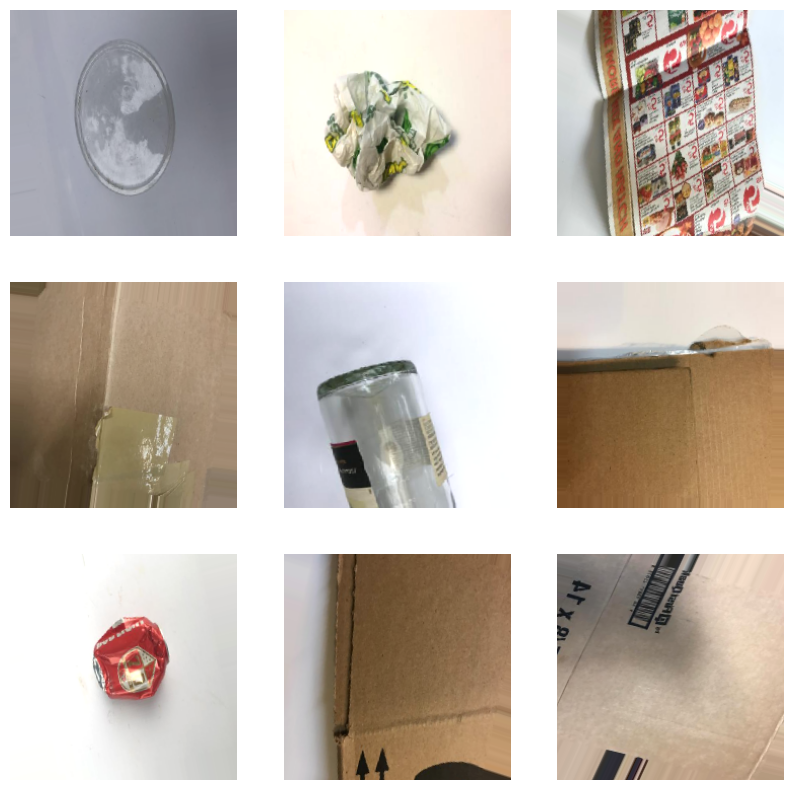

Class Labels: {'non_recyclable': 0, 'organic': 1, 'recyclable': 2}


In [9]:
# Task 2 – Data Preprocessing (5 Marks)
# Perform the following preprocessing steps:

# Resize images to a fixed size (e.g., 224×224)

# Normalize pixel values

# Apply data augmentation (at least 3 techniques)

# Examples:

# Rotation

# Horizontal flip

# Zoom

# Brightness adjustment

# Deliverable:
# • Show the preprocessing pipeline code.


# Import library
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Training Data Preprocessing

train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize pixel values
    rotation_range=20,         # Random rotation
    horizontal_flip=True,      # Flip images
    zoom_range=0.2,            # Zoom augmentation
    brightness_range=[0.8,1.2] # Brightness adjustment
)

# Validation Data Preprocessing

validation_datagen = ImageDataGenerator(
    rescale=1./255
)


# Load Training Dataset

train_data = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)


# Load Validation Dataset

validation_data = validation_datagen.flow_from_directory(
    "/content/dataset/validation",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

# Get one batch of images
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):   # show 9 images
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

# Check Class Labels

print("Class Labels:", train_data.class_indices)

In [11]:
# Task 3 – CNN Model Development (8 Marks)
# Build an image classification model using CNN.

# Your model should include:

# Convolution layers

# Pooling layers

# Dense layers

# Softmax output layer

# Train the model and display:

# Training accuracy

# Validation accuracy

# Training loss curve

# Deliverable:

# • Model architecture
# • Training output
# • Accuracy graph

#Step 1 – Create the CNN Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation="relu"),
    Dropout(0.5),

    Dense(3,activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#Step 2 – Train the Model
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 289s 4s/step - accuracy: 0.8687 - loss: 0.5901 - val_accuracy: 0.8759 - val_loss: 0.4739
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 275s 4s/step - accuracy: 0.8765 - loss: 0.4971 - val_accuracy: 0.8759 - val_loss: 0.4664
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 287s 4s/step - accuracy: 0.8765 - loss: 0.4796 - val_accuracy: 0.8759 - val_loss: 0.4390
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 271s 4s/step - accuracy: 0.8765 - loss: 0.4788 - val_accuracy: 0.8759 - val_loss: 0.4439
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.8765 - loss: 0.4685 - val_accuracy: 0.8759 - val_loss: 0.4505
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 272s 4s/step - accuracy: 0.8765 - loss: 0.4670 - val_accuracy: 0.8759 - val_loss: 0.4410
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 266s 4s/step - accuracy: 0.8765 - loss: 0.4498 - val_accuracy: 0.8759 - val_loss: 0.4331
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.8765 - loss: 0.4502 - val_accuracy: 0.8759 - v

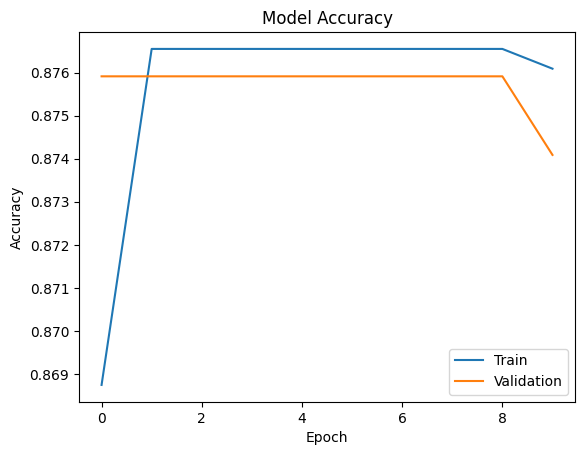

In [14]:
#Step 3: Accuracy Graph
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step


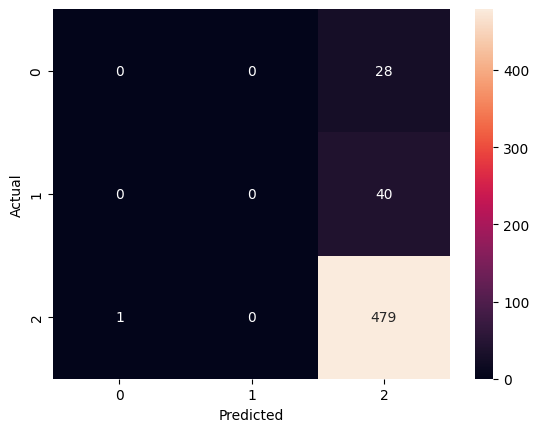

In [15]:
# Task 4 – Model Evaluation (6 Marks)
# Evaluate the trained model using:

# Confusion Matrix

# Accuracy score

# Sample predictions on test images

# Deliverable:

# • Confusion matrix visualization
# • 5 test image predictions with predicted labels


from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns

predictions = model.predict(validation_data)

y_pred = np.argmax(predictions,axis=1)
y_true = validation_data.classes

cm = confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


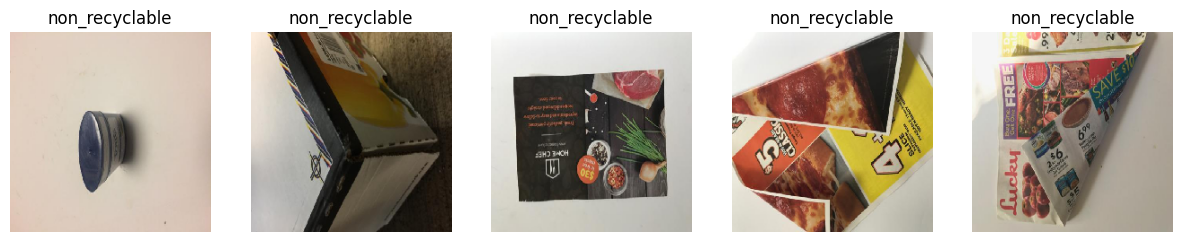

In [16]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

base_path = "/content/dataset/validation"

classes = ["organic","recyclable","non_recyclable"]

image_paths = []

# collect all image paths
for cls in classes:
    class_path = os.path.join(base_path, cls)

    if os.path.exists(class_path):
        for img in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, img))

# select 5 random images
sample_images = random.sample(image_paths, 5)

plt.figure(figsize=(15,5))

for i, img_path in enumerate(sample_images):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_class = classes[np.argmax(prediction)]

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(predicted_class)
    plt.axis("off")

plt.show()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8678 - loss: 0.4409 - val_accuracy: 0.8814 - val_loss: 0.3676
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.8848 - loss: 0.3176 - val_accuracy: 0.8723 - val_loss: 0.3393
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.8954 - loss: 0.2824 - val_accuracy: 0.8741 - val_loss: 0.3256
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8958 - loss: 0.2683 - val_accuracy: 0.8796 - val_loss: 0.3448
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9004 - loss: 0.2513 - val_accuracy: 0.8723 - val_loss: 0.3486
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9059 - loss: 0.2372 - val_accuracy: 0.8777 - val_loss: 0.3341
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9082 - loss: 0.2163 - val_accuracy: 0.8905 - val_loss: 0.3171
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9105 - loss: 0.2081 - val_accuracy: 0.8723 - v

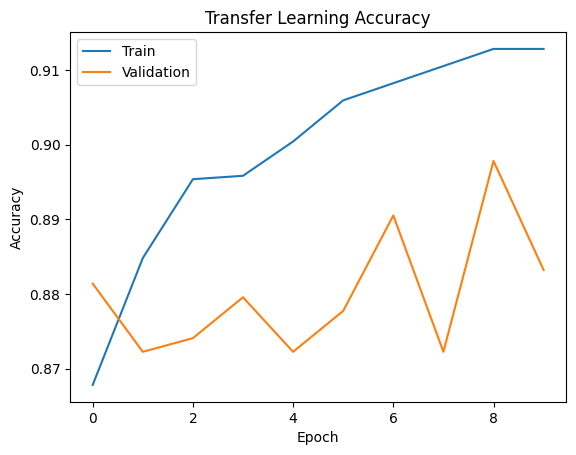

In [17]:
# Task 5 – Transfer Learning Implementation (6 Marks)
# Improve your system by implementing Transfer Learning using a pretrained model such as:

# ResNet50

# MobileNetV2

# VGG16

# Steps:

# Load a pretrained model

# Freeze base layers

# Add custom classification layers

# Train the model

# Compare results with your original CNN model.

# Deliverable:

# • Accuracy comparison between Custom CNN vs Transfer Learning model


# Import libraries
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
import matplotlib.pyplot as plt


# Load Pretrained MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)


# Freeze Base Layers

for layer in base_model.layers:
    layer.trainable = False


# Add Custom Layers

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

predictions = Dense(3, activation="softmax")(x)


# Create Transfer Learning Model

transfer_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=predictions
)


# Compile Model

transfer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# Show Model Summary

transfer_model.summary()


# Train Model

transfer_history = transfer_model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)


# Plot Accuracy Graph

plt.plot(transfer_history.history['accuracy'])
plt.plot(transfer_history.history['val_accuracy'])

plt.title("Transfer Learning Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()
